#### Midterm 
Design the front end of a supersonic train. In engineering terms it is often the case that you want to maximize or minimize some performance metric while staying within some set of constraints

<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/Midterm%20-%20supersonic%20train%20Optimization/Train%20Side%20profile.png?raw=true" width="50%">



#### Strategy 

The total cost(point of optimization) is given by 

$C = 20 \times N \times D$
where 

1. C is optimization point COST
2. N is the number of trips N
3. D is the Drag in newtons 


$N = 2\left\lceil \frac{1}{V} \right\rceil - 1, \qquad 0 < V \le 1$



### Approach Strategy 

1. I will define the dotted line box to have 1 by 1 dimensions. 
<br>

https://www.101computing.net/the-shoelace-algorithm/ <br>

2. I will make a function that takes in the number of vertice and linmaps out the possible vertice coordinates in the region
3. I will make a function that calculates the volume fraction given the vertice locations using the shoelace formula

<br>

4. For the inviscid assumption, I will make a function that calculates the drag given the vertice locations 
5. For the viscocious assumption, [Ask in office hours on this approach]
<br>

6. I will use the two functions for multidomain optimization wtih scipy or pytorch(Look into documentation)
7. I will optimize and find the best possible solutions. 
<br>



Assumptions 

1. Conditions : 
    M = 3 
    T = 300K 
    P = 101325 
    L = 1m  
2. Analysis using the oblique shocks and expansion waves only 
3. Only care about the overall drag in the X direction
4. . This is my assumption. There's no way $\Sigma$ shaped train is better than 'bullet' shaped train. I'll work on its implementation but this is a rule that can minimax filter a lot of cases
5. In the given plane closed by the dotted line, the bottom left is (0,0). The top right is (1,1)

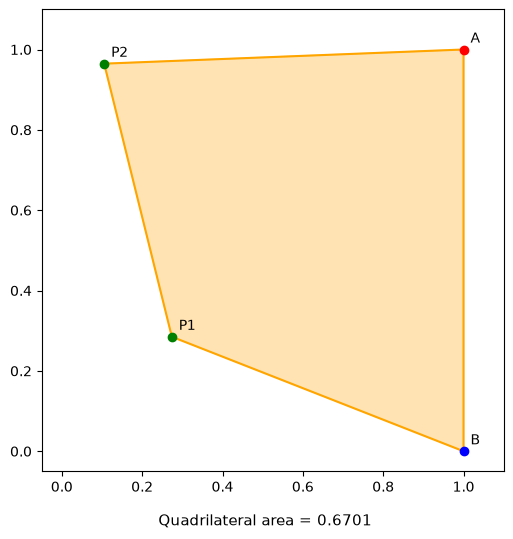

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed points
A = np.array([1.0, 1.0])   # top right
B = np.array([1.0, 0.0])   # bottom right

# Random points in the unit square (continuous uniform, no meshgrid needed)
P_1 = np.random.rand(2)
P_2 = np.random.rand(2)


def order_ccw(pts):
    """Sort vertices counterclockwise by angle about their centroid,
    which gives a simple (non-self-intersecting) polygon."""
    pts = np.asarray(pts, dtype=float)
    c = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    return pts[np.argsort(ang)]


def polygonArea(vertices):
    """Shoelace formula. Vertices must be in order around a simple polygon."""
    n = len(vertices)
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n - 1):
        sum1 += vertices[i][0] * vertices[i + 1][1]
        sum2 += vertices[i][1] * vertices[i + 1][0]
    sum1 += vertices[n - 1][0] * vertices[0][1]   # x_n * y_1
    sum2 += vertices[n - 1][1] * vertices[0][0]   # y_n * x_1
    return abs(sum1 - sum2) / 2


def polygonArea_vec(vertices):
    """Vectorized shoelace, used as an independent cross-check."""
    v = np.asarray(vertices, dtype=float)
    x, y = v[:, 0], v[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


# --- Triangle ABP1: analytic check (base AB lies on x=1, length 1) ---
tri_area = polygonArea([A, B, P_1])
assert np.isclose(tri_area, 0.5 * (1 - P_1[0])), "Triangle area mismatch"

# --- Quadrilateral A, B, P1, P2: order first, then compute and plot the same list ---
quad = order_ccw([A, B, P_1, P_2])
quad_area = polygonArea(quad)
assert np.isclose(quad_area, polygonArea_vec(quad)), "Shoelace implementations disagree"

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))

closed = np.vstack([quad, quad[0]])
ax.fill(quad[:, 0], quad[:, 1], color="orange", alpha=0.3, zorder=1)
ax.plot(closed[:, 0], closed[:, 1], color="orange", zorder=2)

ax.scatter(*A, color="red", zorder=3)
ax.scatter(*B, color="blue", zorder=3)
ax.scatter(*P_1, color="green", zorder=3)
ax.scatter(*P_2, color="green", zorder=3)

for label, p in [("A", A), ("B", B), ("P1", P_1), ("P2", P_2)]:
    ax.annotate(label, p, textcoords="offset points", xytext=(5, 5))

ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.set_aspect("equal")
fig.text(0.5, 0.02,
         f"Quadrilateral area = {quad_area:.4f}",
         ha="center", fontsize=11)
plt.show()